In [11]:
import torch
import torch.nn as nn
from multigrid import BoundaryCondition, laplace_jacobi_step, laplace_jacobi_smoothen
from multigrid import laplace_multigrid_v_cycle, laplace_multigrid_w_cycle, laplace_multigrid_f_cycle, laplace_full_multigrid_v_cycle
from utils import interpolate, restrict, laplace_smoothen
import time
import matplotlib.pyplot as plt

In [2]:
grid_size = (8, 8)

In [3]:
bc = torch.zeros(grid_size)
bc[[0, -1], :] = -1
bc[:, [0, -1]] = -1
bc[2, 3:5] = 1
bcond = BoundaryCondition(bc != 0, bc)

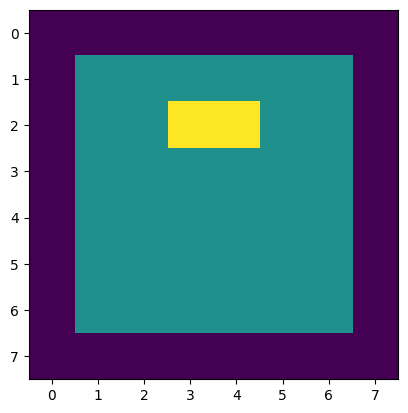

In [4]:
plt.imshow(bcond.vals)

In [5]:
f = bcond.vals

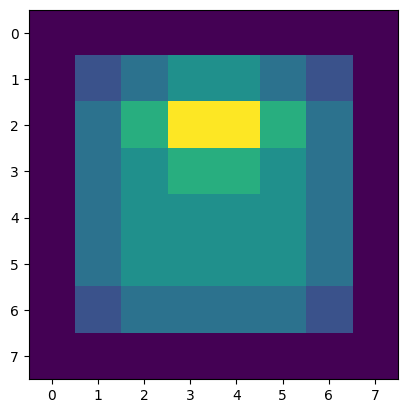

In [6]:
for _ in range(1):
    f = laplace_jacobi_step(f, bcond)
plt.imshow(f)

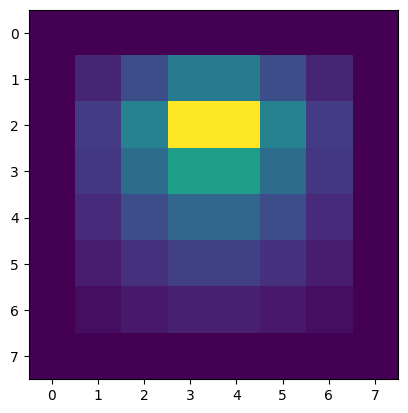

In [8]:
f = laplace_jacobi_smoothen(f, bcond)
plt.imshow(f)

In [11]:
f_interp = interpolate(f)

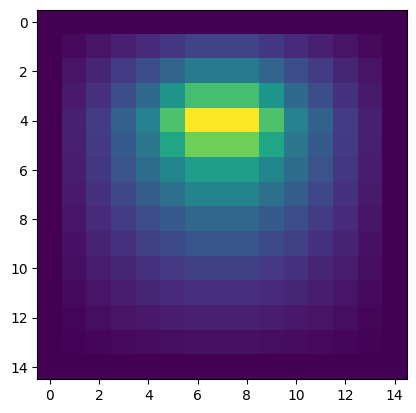

In [12]:
plt.imshow(f_interp)

## Starting with fine grid

In [2]:
res = 256

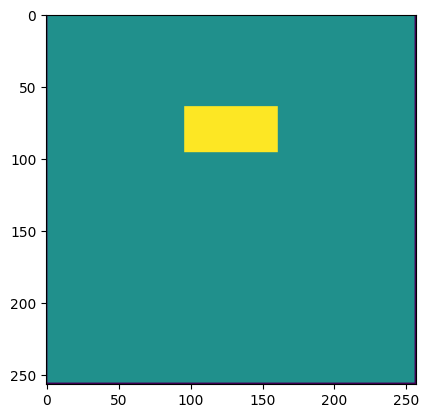

In [3]:
bc = torch.zeros(res+1, res+1)
bc[[0, -1], :] = -1
bc[:, [0, -1]] = -1
bc[2*32:3*32, 3*32:5*32+1] = 1
bcond = BoundaryCondition(bc != 0, bc)
plt.imshow(bcond.vals)

In [4]:
f = bcond.vals

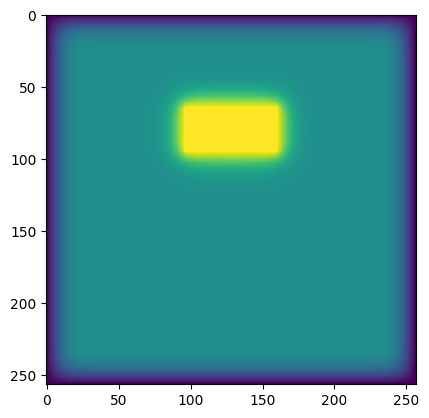

In [5]:
f_smooth = laplace_jacobi_smoothen(f, bcond, tol=1e-5)
plt.imshow(f_smooth)

In [9]:
f_smooth = laplace_multigrid_v_cycle(f, bcond, tol=1e-5)

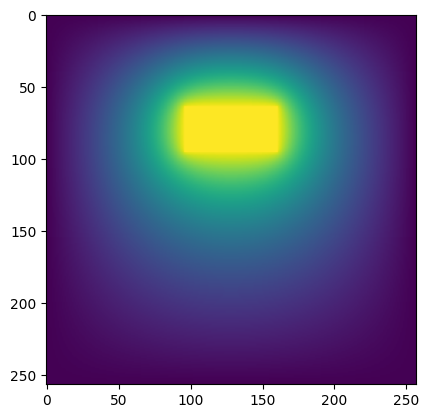

In [10]:
plt.imshow(f_smooth)

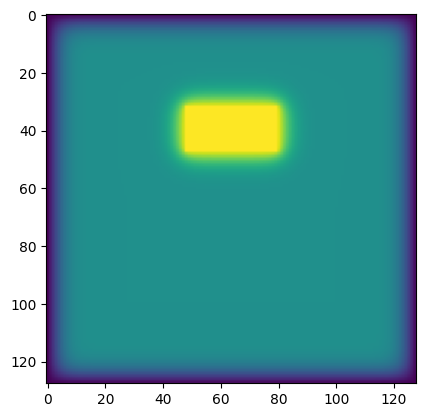

In [8]:
plt.imshow(restrict(f_smooth))
plt.show()

## Using TUM logo

In [2]:
from PIL import Image
from torchvision.transforms.functional import pil_to_tensor
def open_image(fname: str) -> torch.Tensor:
    img = Image.open(fname)
    return pil_to_tensor(img)

In [3]:
tum_logo = open_image('tum.png')
tum_alpha = (tum_logo[3] != 0).float() # (280, 280)

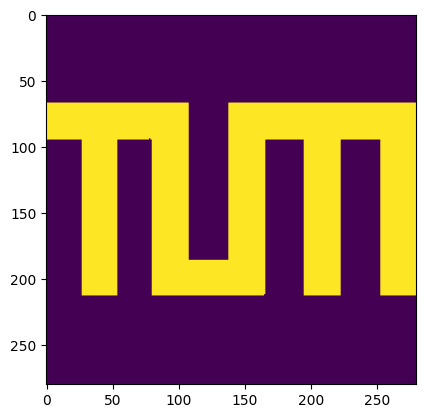

In [4]:
plt.imshow(tum_logo[3] != 0)

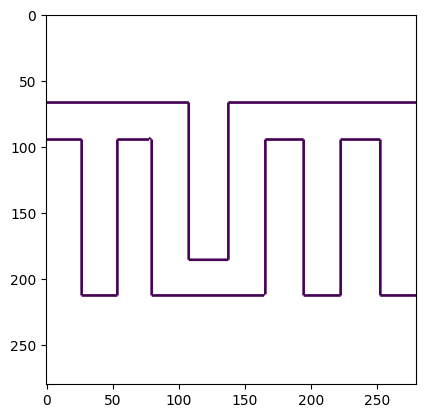

In [49]:
# tum_alpha[:, 80:166] *= -1
plt.imshow(torch.zeros_like(laplace_smoothen(tum_alpha) != tum_alpha), alpha=(laplace_smoothen(tum_alpha) != tum_alpha).float())

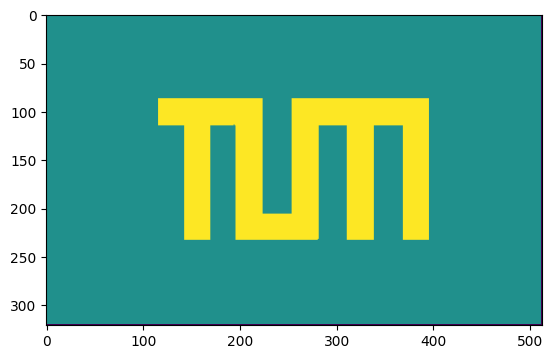

In [5]:
bc = torch.zeros(321, 513)
# bc[[0, -1], :] = torch.tensor((0.5, -0.5)).unsqueeze(-1)
# bc[:, [0, -1]] = torch.linspace(0.5, -0.5, 321).unsqueeze(-1)
bc[[0, -1], :] = -1
bc[:, [0, -1]] = -1
bc[20:20+280,116:116+280] = tum_alpha
bcond = BoundaryCondition(bc != 0, bc)
plt.imshow(bcond.vals)
plt.show()

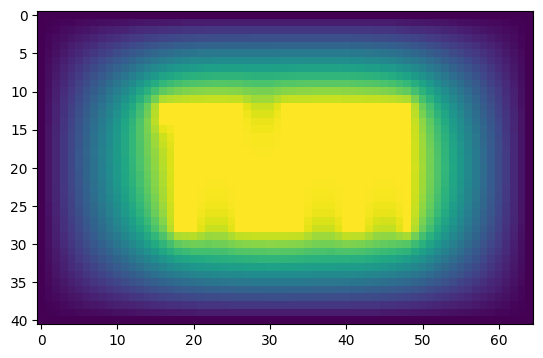

In [16]:
plt.imshow(interpolate(laplace_jacobi_smoothen(bcond.restrict().restrict().restrict().restrict().vals, bcond.restrict().restrict().restrict().restrict())))
plt.show()

In [6]:
tum_outline = (laplace_smoothen(bc) != bc).float()

Runtime: 0.18638s


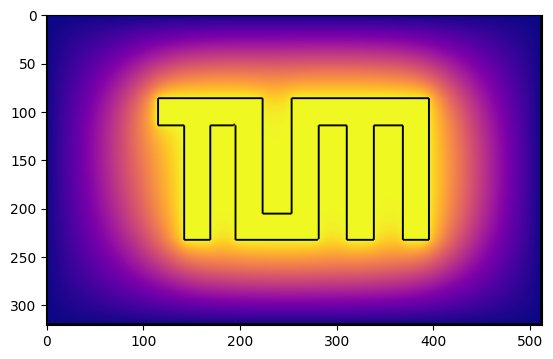

In [19]:
f = bcond.vals
start = time.time()
f_smooth = laplace_multigrid_v_cycle(f, bcond, tol=1e-4, maxiter=200)
end = time.time()
print(f'Runtime: {end - start:.5f}s')
plt.imshow(f_smooth, cmap='plasma')
plt.imshow(torch.zeros_like(f), alpha=tum_outline, cmap='gray')

Runtime: 0.25360s


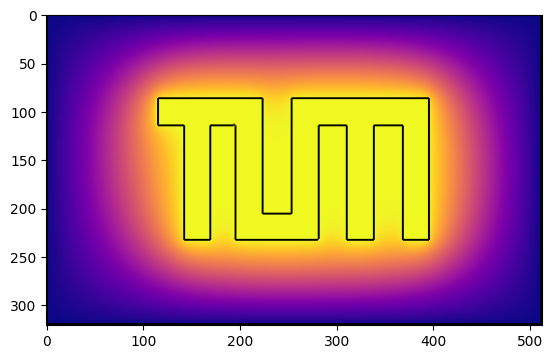

In [12]:
f = bcond.vals
start = time.time()
f_smooth = laplace_multigrid_f_cycle(f, bcond, tol=1e-4, maxiter=200)
end = time.time()
print(f'Runtime: {end - start:.5f}s')
plt.imshow(f_smooth, cmap='plasma')
plt.imshow(torch.zeros_like(f), alpha=tum_outline, cmap='gray')

Runtime: 0.24090s


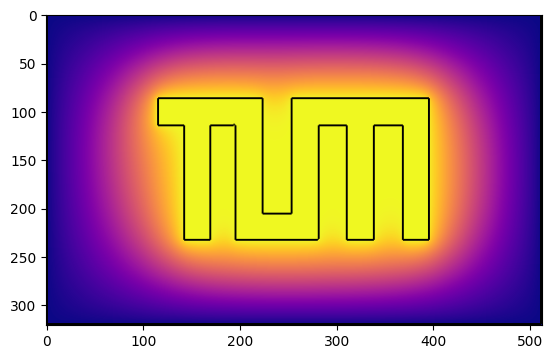

In [16]:
f = bcond.vals
start = time.time()
f_smooth = laplace_multigrid_w_cycle(f, bcond, tol=1e-4, maxiter=200)
end = time.time()
print(f'Runtime: {end - start:.5f}s')
plt.imshow(f_smooth, cmap='plasma')
plt.imshow(torch.zeros_like(f), alpha=tum_outline, cmap='gray')

Runtime: 0.07281s


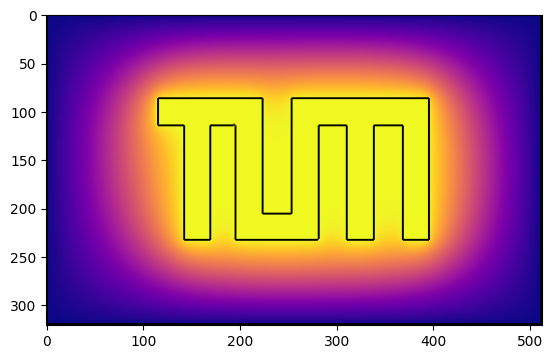

In [14]:
f = bcond.vals
start = time.time()
f_smooth = laplace_full_multigrid_v_cycle(f, bcond, tol=1e-4, maxiter=200)
end = time.time()
print(f'Runtime: {end - start:.5f}s')
plt.imshow(f_smooth, cmap='plasma')
plt.imshow(torch.zeros_like(f), alpha=tum_outline, cmap='gray')

## Other boundary conditions

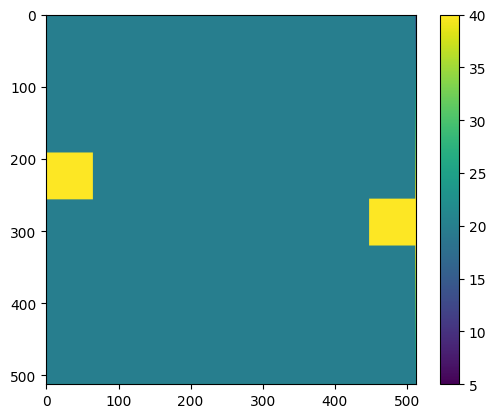

In [56]:
n = 512
bc = torch.full((n+1, n+1), 20.)

bc[0, :n//2] = torch.linspace(13, 5, n//2)
bc[0, n//2:3*n//4] = 5
bc[0, 3*n//4:] = torch.linspace(5, 13, n//4+1)

bc[-1] = 21

bc[:3*n//8, 0] = torch.linspace(13, 40, 3*n//8)
bc[n//2+1:, 0] = torch.linspace(40, 21, n//2)

bc[:n//2, -1] = torch.linspace(13, 40, n//2)
bc[5*n//8+1:, -1] = torch.linspace(40, 21, 3*n//8)

bc[3*n//8:n//2+1, :n//8+1] = 40
bc[n//2:5*n//8+1, 7*n//8:] = 40

bcond = BoundaryCondition(bc != 20, bc)
plt.imshow(bcond.vals)
plt.colorbar()
plt.show()

Runtime: 0.08504s


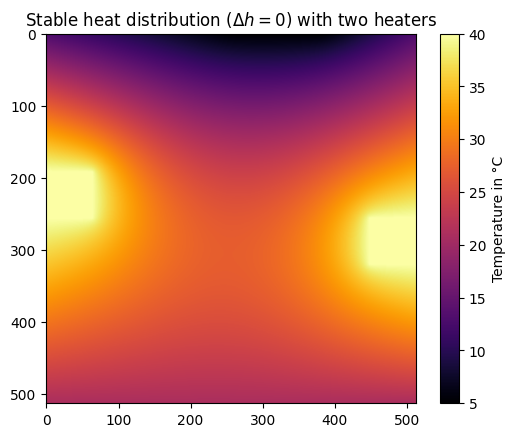

In [64]:
f = bcond.vals
start = time.time()
f_smooth = laplace_full_multigrid_v_cycle(f, bcond, depth=4, tol=1e-4, maxiter=200)
# f_smooth = laplace_jacobi_smoothen(f, bcond, tol=1e-4, maxiter=1000)
end = time.time()
print(f'Runtime: {end - start:.5f}s')
plt.imshow(f_smooth, cmap='inferno')
plt.colorbar(label='Temperature in °C')
plt.title('Stable heat distribution ($\\Delta h = 0$) with two heaters')
plt.show()